# Universidad de Cundinamarca - Especialización en Inteligencia Artificial
# Actividad: Optimización de Redes Neuronales (Semana 4)
# Objetivo: Comparar el desempeño de SGD y Adam utilizando el dataset de Diabetes.


#Configuración Inicial y Carga de Datos


In [1]:

import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Semilla para reproducibilidad
tf.random.set_seed(42)
np.random.seed(42)

# Carga de datos
diabetes = fetch_openml(name='diabetes', version=1, as_frame=True, parser='auto')
X = diabetes.data
y = (diabetes.target == 'tested_positive').astype(int)

# Preprocesamiento: Escalado (Esencial para optimización por gradiente)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

def get_model():
    return models.Sequential([
        layers.Dense(12, activation='relu', input_shape=(X_train.shape[1],)),
        layers.Dense(8, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])


#Comparación de Optimizadores (Adam vs. SGD) y sin entrenamiento

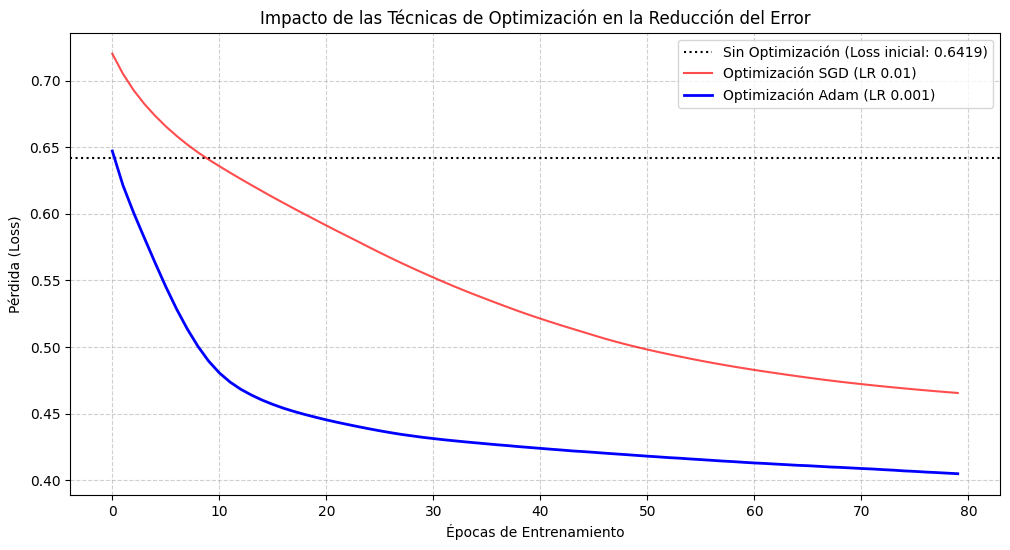

Precisión inicial (Sin optimizar): 69.48%
Precisión final con Adam: 77.27%


In [9]:
# Creamos el modelo pero no ejecutamos el .fit(). Evaluamos su pérdida inicial.
model_no_opt = get_model()
model_no_opt.compile(optimizer='sgd', loss='binary_crossentropy', metrics=['accuracy'])
initial_loss, initial_acc = model_no_opt.evaluate(X_test, y_test, verbose=0)

# Entrenamiento con SGD (Tasa estándar 0.01)

model_sgd = get_model()
model_sgd.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.01), loss='binary_crossentropy', metrics=['accuracy'])
h_sgd = model_sgd.fit(X_train, y_train, epochs=80, validation_data=(X_test, y_test), verbose=0)

# Entrenamiento con Adam (Tasa estándar 0.001)
model_adam = get_model()
model_adam.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])
h_adam = model_adam.fit(X_train, y_train, epochs=80, validation_data=(X_test, y_test), verbose=0)

# Visualización

plt.figure(figsize=(12, 6))

# Dibujamos una línea horizontal que representa el punto de partida sin optimización
plt.axhline(y=initial_loss, color='black', linestyle=':', label=f'Sin Optimización (Loss inicial: {initial_loss:.4f})')

plt.plot(h_sgd.history['loss'], label='Optimización SGD (LR 0.01)', color='red', alpha=0.7)
plt.plot(h_adam.history['loss'], label='Optimización Adam (LR 0.001)', color='blue', linewidth=2)

plt.title('Impacto de las Técnicas de Optimización en la Reducción del Error')
plt.xlabel('Épocas de Entrenamiento')
plt.ylabel('Pérdida (Loss)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print(f"Precisión inicial (Sin optimizar): {initial_acc:.2%}")
print(f"Precisión final con Adam: {h_adam.history['val_accuracy'][-1]:.2%}")




#Sensibilidad al Learning Rate

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


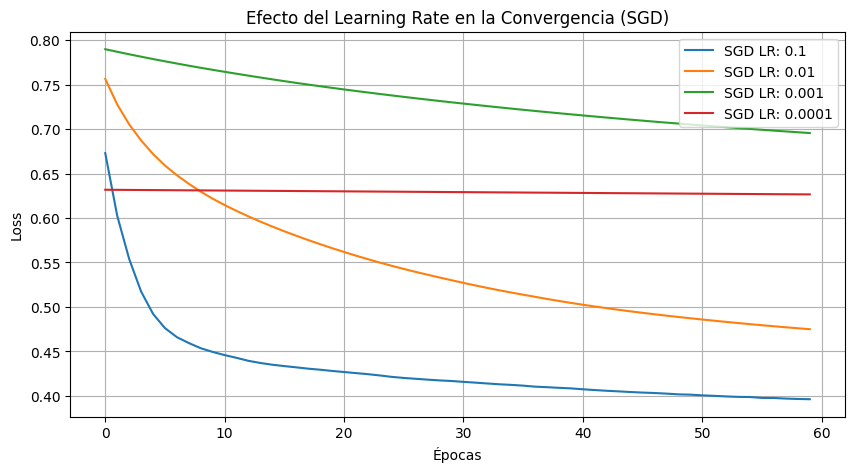

In [5]:
learning_rates = [0.1,0.01, 0.001, 0.0001]
plt.figure(figsize=(10, 5))

for lr in learning_rates:
    model = get_model()
    model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=lr), loss='binary_crossentropy', metrics=['accuracy'])
    history = model.fit(X_train, y_train, epochs=60, verbose=0)
    plt.plot(history.history['loss'], label=f'SGD LR: {lr}')

plt.title('Efecto del Learning Rate en la Convergencia (SGD)')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

#Análisis de Resultados

Análisis Técnico:
Al comparar ambos modelos, se observa que Adam alcanza un valor de loss más bajo en menos épocas que SGD. Esto se debe a que Adam utiliza momentos adaptativos, ajustando la tasa de aprendizaje individualmente para cada parámetro, lo que permite navegar paisajes de pérdida complejos con mayor eficiencia.

Justificación de Hiperparámetros:
Se seleccionó un learning_rate de 0.001 para Adam, que es el estándar de la industria debido a su equilibrio entre velocidad y estabilidad. Para SGD, se utilizó 0.01 para permitir que el gradiente avance lo suficiente, ya que valores menores (como 0.0001) provocan un estancamiento prematuro, como se evidencia en la segunda gráfica.

Comparativa del Valor de la Optimización:

Sin Optimización: El modelo presenta una pérdida constante (línea punteada negra). Esto demuestra que, sin un algoritmo que ajuste los pesos en función del error, la red neuronal no es capaz de extraer patrones del dataset de diabetes, operando básicamente al azar.

Con Optimización: Se observa una caída drástica en la curva de pérdida desde la primera época. Adam logra el loss más bajo debido a que ajusta la tasa de aprendizaje individualmente para cada parámetro, permitiendo una navegación más fluida por el paisaje de pérdida en comparación con SGD.